<a href="https://colab.research.google.com/github/nidhita2/Deep-Learning/blob/main/surgical_operations_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload the surgical operation image
from google.colab import files
uploaded = files.upload()

Saving team-surgery.webp to team-surgery.webp


In [2]:
import os
print(os.listdir("/content"))

['.config', 'team-surgery.webp', 'sample_data']


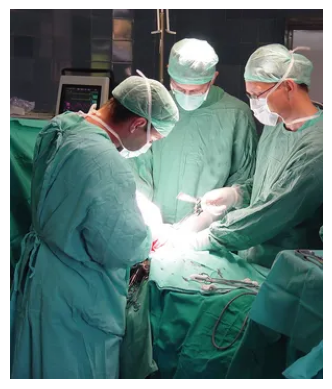

In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
image = load_img("/content/team-surgery.webp")
plt.imshow(image)
plt.axis("off")
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import (load_img, img_to_array, ImageDataGenerator)

In [7]:
image = load_img("/content/team-surgery.webp")
image_array = img_to_array(image)

In [8]:
# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)
print("Image shape", image_array.shape)

Image shape (1, 355, 300, 3)


In [9]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [10]:
augmentation_generator = datagen.flow(image_array, batch_size=1)

In [11]:
# Define output folder and create if it doesn't exist
from tensorflow.keras.preprocessing.image import array_to_img
import os

output_folder = "/content/augmented_surgical_images"
os.makedirs(output_folder, exist_ok=True)

# Create augmentation generator
augmentation_generator = datagen.flow(
    image_array,
    batch_size=1
)

# Generate and save 200 images
for i in range(200):

    augmented_image = next(augmentation_generator)[0]

    # Convert array to image
    img = array_to_img(augmented_image)

    # Save image
    image_path = f"{output_folder}/surgical_augmented_{i+1}.jpg"

    img.save(image_path)

    print("Saved:", image_path)

Saved: /content/augmented_surgical_images/surgical_augmented_1.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_2.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_3.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_4.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_5.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_6.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_7.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_8.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_9.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_10.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_11.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_12.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_13.jpg
Saved: /content/augmented_surgical_images/surgical_augmented_14.jpg
Saved: /content/augmented_surgical_images/surgical_augmen

In [12]:
import shutil

shutil.make_archive(
    "/content/augmented_surgical_images",
    "zip",
    output_folder
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [13]:
from google.colab import files

files.download("/content/augmented_surgical_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>